## Задание №1

In [1]:
# t1 - интервал между поступлениями сигналов
t1_min = 1
t1_max = 4

# t2 - время обработки сигнала
t2_min = 1
t2_max = 4

In [2]:
import numpy as np

def generate_signals(n, t1_min, t1_max, t2_min, t2_max, seed=None):
    if seed is not None:
        np.random.seed(seed)

    # интервалы прихода
    t1 = np.random.uniform(t1_min, t1_max, n)

    # моменты прихода (накопление)
    arrival_times = np.cumsum(t1)

    # время обработки
    service_times = np.random.uniform(t2_min, t2_max, n)

    return arrival_times, service_times

In [3]:
def simulate(arrival_times, service_times):
    n = len(arrival_times)

    processed = 0
    server_free_time = 0  # когда сервер освободится

    for i in range(n):
        arrival = arrival_times[i]
        service = service_times[i]

        # если сервер свободен
        if arrival >= server_free_time:
            processed += 1
            server_free_time = arrival + service
        # иначе сигнал теряется

    return processed / n

In [4]:
n = 10000

arrival_times, service_times = generate_signals(
    n,
    t1_min=1, t1_max=4,
    t2_min=1, t2_max=4,
    seed=42
)

P = simulate(arrival_times, service_times)

print("Доля обработанных сигналов:", round(P, 4))

Доля обработанных сигналов: 0.6377


In [16]:
arrival_times, service_times = generate_signals(
    10000,
    t1_min=3, t1_max=4,
    t2_min=1, t2_max=2,
    seed=42
)

print("Тест 1 (должно быть близко к 1):", simulate(arrival_times, service_times))

Тест 1 (должно быть близко к 1): 1.0


In [20]:
arrival_times, service_times = generate_signals(
    10000,
    t1_min=1, t1_max=2,
    t2_min=3, t2_max=4,
    seed=42
)

print("Тест 2 (должно быть меньше 0.5):", simulate(arrival_times, service_times))

Тест 2 (должно быть меньше 0.5): 0.3462


## Задание №2

In [7]:
def simulate_system(n, Tz, Ts, seed=None):
    # Tz - средний интервал поступления
    # Ts - среднее время обработки
    if seed is not None:
        np.random.seed(seed)

    # равномерное распределение вокруг среднего
    arrival_intervals = np.random.uniform(0.5*Tz, 1.5*Tz, n)
    service_times = np.random.uniform(0.5*Ts, 1.5*Ts, n)

    arrival_times = np.cumsum(arrival_intervals)

    return simulate(arrival_times, service_times)

In [8]:
print(simulate_system(10000, Tz=2, Ts=2, seed=42))

0.6489


## Задание №3

Matplotlib is building the font cache; this may take a moment.


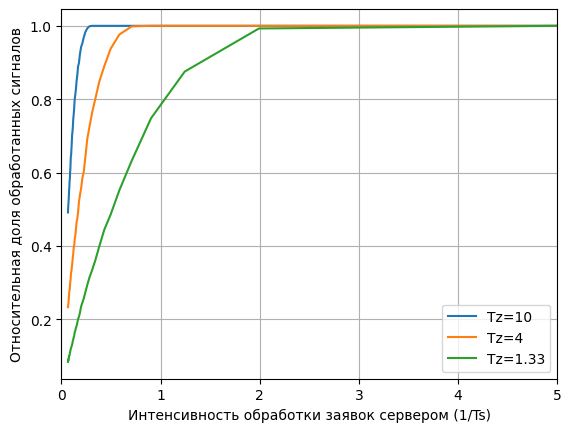

In [9]:
import matplotlib.pyplot as plt

def plot_processing_vs_service():
    Tz_values = [10, 4, 1.33]
    Ts_range = np.linspace(0.2, 15, 50)

    for Tz in Tz_values:
        results = []
        for Ts in Ts_range:
            P = simulate_system(5000, Tz, Ts)
            results.append(P)

        intensity = 1 / Ts_range
        plt.plot(intensity, results, label=f"Tz={Tz}")

    # μ
    plt.xlabel("Интенсивность обработки заявок сервером (1/Ts)")
    plt.ylabel("Относительная доля обработанных сигналов")
    plt.legend()
    plt.grid()
    plt.xlim(0, 5)
    plt.show()

plot_processing_vs_service()

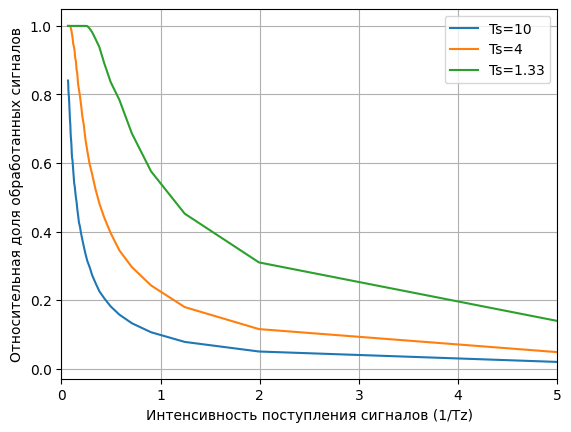

In [10]:
def plot_processing_vs_arrival():
    Ts_values = [10, 4, 1.33]
    Tz_range = np.linspace(0.2, 15, 50)

    for Ts in Ts_values:
        results = []
        for Tz in Tz_range:
            P = simulate_system(5000, Tz, Ts)
            results.append(P)

        intensity = 1 / Tz_range
        plt.plot(intensity, results, label=f"Ts={Ts}")

    # λ
    plt.xlabel("Интенсивность поступления сигналов (1/Tz)")
    plt.ylabel("Относительная доля обработанных сигналов")
    plt.legend()
    plt.grid()
    plt.xlim(0, 5)
    plt.show()

plot_processing_vs_arrival()

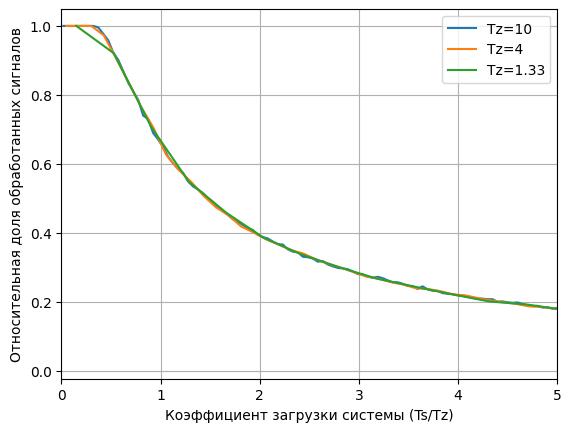

In [ ]:
def plot_processing_vs_load():
    Tz_values = [10, 4, 1.33]
    Ts_range = np.linspace(0.2, 50, 100)

    for Tz in Tz_values:
        results = []
        rho_values = []

        for Ts in Ts_range:
            P = simulate_system(5000, Tz, Ts)
            results.append(P)
            rho_values.append(Ts / Tz)

        plt.plot(rho_values, results, label=f"Tz={Tz}")

    # ro
    plt.xlabel("Коэффициент загрузки системы (Ts/Tz)")
    plt.ylabel("Относительная доля обработанных сигналов")
    plt.legend()
    plt.grid()
    plt.xlim(0, 5)
    plt.show()

plot_processing_vs_load()

При увеличении интенсивности обработки сервером доля обработанных сигналов возрастает.

При увеличении интенсивности входного потока доля обработанных сигналов уменьшается.

При коэффициенте загрузки ro >= 1 система переходит в режим перегрузки.

Для устойчивой работы необходимо ro < 1.